# process heat integration cement retrofit NPV simulation

Run the process heat integration cement retrofit Monte Carlo simulation and visualize the resulting NPV distribution.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from cement.cement_npv_monte_carlo import (
    DEFAULT_RANDOM_SEED,
    DEFAULT_RETROFIT_BAU_MODE,
    DEFAULT_SAMPLE_SIZE,
    simulate_cement_results,
)


In [2]:
TECHNOLOGY = 'process_heat_integration'
SAMPLE_SIZE = DEFAULT_SAMPLE_SIZE
RANDOM_SEED = DEFAULT_RANDOM_SEED
RETROFIT_BAU_MODE = DEFAULT_RETROFIT_BAU_MODE

results_by_technology = simulate_cement_results(
    sample_size=SAMPLE_SIZE,
    random_seed=RANDOM_SEED,
    technologies=(TECHNOLOGY,),
    retrofit_bau_mode=RETROFIT_BAU_MODE,
)
simulation = results_by_technology[TECHNOLOGY]
results = pd.DataFrame(simulation)
results.head()


,run_id,technology,technology_type,retrofit_bau_mode,annual_output_t,capex_eur_per_t,fixed_opex_eur_per_t,variable_opex_eur_per_t,fuel_consumption_mwh_th_per_t,electricity_consumption_mwh_per_t,...,bau_variable_opex_eur_per_t,bau_fuel_consumption_mwh_th_per_t,bau_electricity_consumption_mwh_per_t,bau_emissions_tco2_per_t,capex_change_eur_per_t,fixed_opex_change_eur_per_t,variable_opex_change_eur_per_t,fuel_consumption_reduction_fraction,electricity_consumption_reduction_fraction,emissions_reduction_fraction
0,0,process_heat_integration,retrofit,sampled,1000000.0,167.827224,14.984572,5.135369,0.584015,0.084504,...,5.135369,0.657332,0.084504,0.620035,2.348103,0.046663,0.0,0.111538,0.0,0.100032
1,1,process_heat_integration,retrofit,sampled,1000000.0,161.568703,15.413203,5.125930,0.557664,0.093378,...,5.125930,0.649577,0.093378,0.602551,2.791134,0.466285,0.0,0.141497,0.0,0.110299
2,2,process_heat_integration,retrofit,sampled,1000000.0,168.489111,14.874162,5.431670,0.620813,0.085678,...,5.431670,0.697878,0.085678,0.683904,1.317152,0.409912,0.0,0.110428,0.0,0.106319
3,3,process_heat_integration,retrofit,sampled,1000000.0,174.004770,14.168723,5.260010,0.501263,0.089539,...,5.260010,0.693428,0.089539,0.634547,10.057409,0.166994,0.0,0.277123,0.0,0.087125
4,4,process_heat_integration,retrofit,sampled,1000000.0,157.930355,15.126591,5.371749,0.613260,0.084480,...,5.371749,0.694798,0.084480,0.652753,6.046808,0.406913,0.0,0.117355,0.0,0.012396


In [3]:
npv_million_eur = results["npv_eur"] / 1_000_000
npv_eur_per_t = results["npv_eur_per_t"]

summary = pd.concat(
    [
        npv_million_eur.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV million EUR"
        ),
        npv_eur_per_t.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV EUR/t"
        ),
    ],
    axis=1,
)
summary


,NPV million EUR,NPV EUR/t
count,100000.000000,100000.000000
mean,475.699439,19.027978
std,46.619415,1.864777
min,286.530067,11.461203
5%,398.908800,15.956352
50%,475.438156,19.017526
95%,552.853289,22.114132
max,637.632068,25.505283


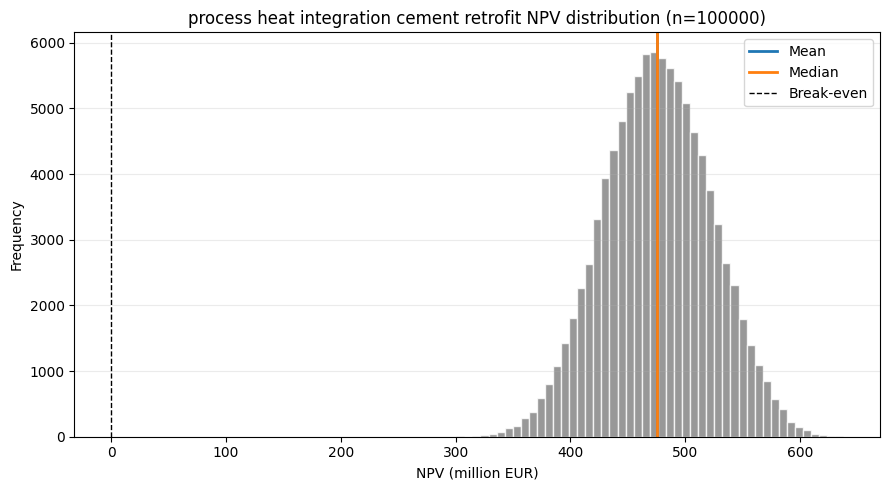

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(npv_million_eur, bins=50, color="tab:gray", edgecolor="white", alpha=0.8)
ax.axvline(npv_million_eur.mean(), color="tab:blue", linewidth=2, label="Mean")
ax.axvline(npv_million_eur.median(), color="tab:orange", linewidth=2, label="Median")
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"process heat integration cement retrofit NPV distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("NPV (million EUR)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()


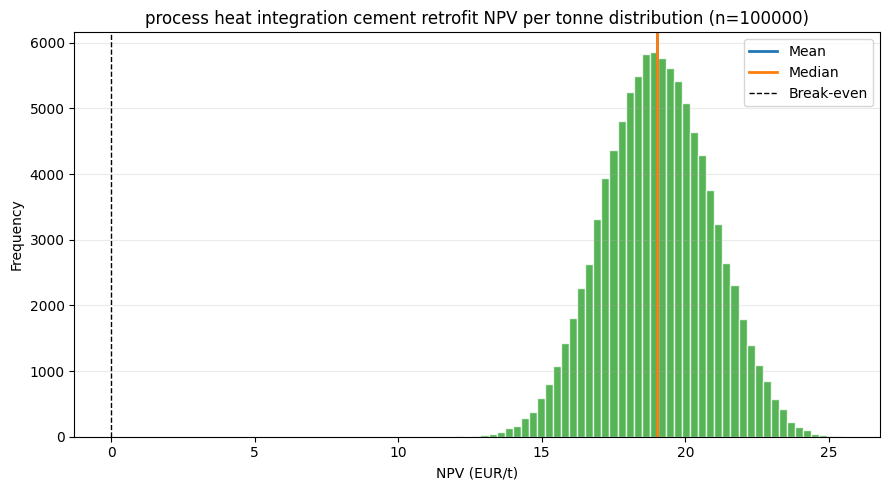

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    npv_eur_per_t,
    bins=50,
    color="tab:green",
    edgecolor="white",
    alpha=0.8,
)
ax.axvline(
    npv_eur_per_t.mean(),
    color="tab:blue",
    linewidth=2,
    label="Mean",
)
ax.axvline(
    npv_eur_per_t.median(),
    color="tab:orange",
    linewidth=2,
    label="Median",
)
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"process heat integration cement retrofit NPV per tonne distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("NPV (EUR/t)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()


In [6]:
annual_components = results[
    [
        "annual_revenue_eur",
        "annual_fixed_opex_eur",
        "annual_variable_opex_eur",
        "annual_fuel_cost_eur",
        "annual_electricity_cost_eur",
        "annual_emissions_cost_eur",
        "annual_net_cash_flow_eur",
    ]
] / 1_000_000

annual_components.mean().rename("Mean annual value, million EUR")


annual_revenue_eur             150.000000
annual_fixed_opex_eur           14.582274
annual_variable_opex_eur         5.167223
annual_fuel_cost_eur             6.745018
annual_electricity_cost_eur     15.926099
annual_emissions_cost_eur       47.371377
annual_net_cash_flow_eur        60.208010
Name: Mean annual value, million EUR, dtype: float64

In [7]:
retrofit_columns = [
    "capex_change_eur_per_t",
    "fixed_opex_change_eur_per_t",
    "variable_opex_change_eur_per_t",
    "fuel_consumption_reduction_fraction",
    "electricity_consumption_reduction_fraction",
    "emissions_reduction_fraction",
    "bau_capex_eur_per_t",
    "bau_fixed_opex_eur_per_t",
    "bau_variable_opex_eur_per_t",
    "bau_fuel_consumption_mwh_th_per_t",
    "bau_electricity_consumption_mwh_per_t",
    "bau_emissions_tco2_per_t",
]

available_retrofit_columns = [column for column in retrofit_columns if column in results]
retrofit_summary = results[available_retrofit_columns].describe(
    percentiles=[0.05, 0.5, 0.95]
)
retrofit_summary


,capex_change_eur_per_t,fixed_opex_change_eur_per_t,variable_opex_change_eur_per_t,fuel_consumption_reduction_fraction,electricity_consumption_reduction_fraction,emissions_reduction_fraction,bau_capex_eur_per_t,bau_fixed_opex_eur_per_t,bau_variable_opex_eur_per_t,bau_fuel_consumption_mwh_th_per_t,bau_electricity_consumption_mwh_per_t,bau_emissions_tco2_per_t
count,100000.000000,100000.000000,100000.0,100000.000000,100000.0,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,6.995092,0.249866,0.0,0.164723,0.0,0.065102,160.012499,14.332408,5.167223,0.666500,0.086635,0.633377
std,3.465419,0.144620,0.0,0.077863,0.0,0.031791,5.770418,0.471200,0.235343,0.040049,0.004713,0.023522
min,1.000047,0.000017,0.0,0.030001,0.0,0.010002,150.000263,13.009529,4.504187,0.610000,0.080000,0.600000
5%,1.602475,0.024669,0.0,0.043582,0.0,0.015464,150.989862,13.451564,4.725440,0.614265,0.080499,0.602579
50%,6.981860,0.249361,0.0,0.164540,0.0,0.065189,160.049191,14.411204,5.207742,0.659535,0.085806,0.629393
95%,12.401921,0.475026,0.0,0.286126,0.0,0.114622,169.007981,14.949464,5.474133,0.741932,0.095517,0.677623
max,12.999980,0.500000,0.0,0.299999,0.0,0.120000,169.999875,14.999998,5.499993,0.779352,0.099946,0.699866
